## Intercomparison of inverse modelling results

This notebook contains options to plot and compare results from different inverse models. The following variables can be investigated:

- Posterior and prior country fluxes, total from all sectors, and respective uncertainties
- Observed and posterior/prior modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior bias mole fractions
- Posterior and prior mole fractions from the outer regions
- Observed repeatability/variability, model and total uncertainties
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Input data:

- Flux and concentration netCDF files with model outputs
- json files with models, sites and species information
- (optional) netCDF file with country fluxes from bottom-up inventory
- (optional) netCDF file with baseline timestamps

Please refer to the User Guide for information on files format, filename convention and folder structure.

### Notebook setup:

1. Decide the verbosity level by assigning the logging level to `logging.INFO` or `logging.WARNING`.

2. Edit the `data_dir` to point towards where the model output is.

3. Set `presentation_mode` to `True`/`False` to use big font sizes (recommended for slides) or small font sizes (recommended for text documents). 

4. Update the `experiments` dictionary so that each key points towards the models you want to plot.

5. Run the cell below, before running any of the plotting code.

In [ ]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.WARNING)

from fluxy.config import set_print_settings
from fluxy.io import read_config_files

### Path to results directory 
data_dir = '/project/hes134/projects/inversion/2025_FIA/results/summary'
plot_dir = '/project/hes134/projects/inversion/2025_FIA/results/summary/fluxy_plots'

### Set presentation_mode to True for bigger fonts
presentation_mode = True

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['InTEM_NAME_EUROPE_EDGAR_std', 'ELRIS_NAME_EUROPE_EDGAR_std', 'RHIME_NAME_EUROPE_EDGAR_std'],
               'wetcharts'     :['InTEM_NAME_EUROPE_EDGARWETCHART_31sites_std','ELRIS_NAME_EUROPE_EDGARWETCHART_31base',
                                 'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_std_31sites'],
                'fia'          :["ELRIS_FLEXPART_EUROPE_POPULATION",
                                 "ELRIS_NAME_EUROPE_POPULATION", 
                                 'ELRIS_FLEXPART_EUROPE_UNIFORM', 
                                 "ELRIS_NAME_EUROPE_UNIFORM", 
                                 "ELRIS_FLEXPART_EUROPE_UNILAND", 
                                 "ELRIS_NAME_EUROPE_UNILAND"],
                'iso'          :["ELRIS_FLEXPART_EUROPE_POPULATIONplus",
                                 "ELRIS_NAME_EUROPE_POPULATIONplus", 
                                 'ELRIS_FLEXPART_EUROPE_UNIFORMplus', 
                                 "ELRIS_NAME_EUROPE_UNIFORMplus", 
                                 "ELRIS_FLEXPART_EUROPE_UNILAND", 
                                 "ELRIS_NAME_EUROPE_UNILAND"]
               
              }

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

### 1. Timeseries of country/region fluxes

##### Edit and run this cell to read and pre-process the data:

In [18]:
from fluxy.io import read_model_output, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels
from fluxy.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'sevoflurane' #options for individual species, or 'all_hfc' or 'all_pfc'
models = experiments['fia'] #if using 'all_hfc' or 'all_pfc' use basic model names  (e.g. ['InTEM','ELRIS','RHIME']) and standard filenames (listed in config_data["models_info"]["standard_run"]["default"]) will be used for each species. 
                                #To use non standard filenames, do <model>_<config_key> : e.g. with ['ELRIS_elris-n2o'], the filenames will be looked in config_data["models_info"]["standard_run"]["elris-n2o"].
regions = ['GERMANY','UK','BENELUX','NW_EU2']
period = 'yearly' #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
country_flux_units_print = 'Gg yr-1' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = '2014-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2025-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
get_labels_from_file = True  # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = None  # if not None, adds sector level results by scaling model totals by the sector proportions in this file. Default file: 'EUROPE_EDGAR', inside the 'sector_flux' directory
create_region_sector_totals = True #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
read_standard_run = False
###################################

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period,read_standard_run=read_standard_run)
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

if sector_file is not None:
    ds_all_flux_scaled = scale_by_sector_proportions(data_dir=data_dir,ds_all=ds_all_flux_scaled,
                                                            species=species,
                                                            country_flux_units_print=country_flux_units_print,
                                                            config_data=config_data,regions=regions,
                                                            sector_file=sector_file,create_region_sector_totals=create_region_sector_totals)   

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

/newhome/hes134/miniconda3/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/newhome/hes134/miniconda3/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become dis

#### Timeseries of country fluxes:

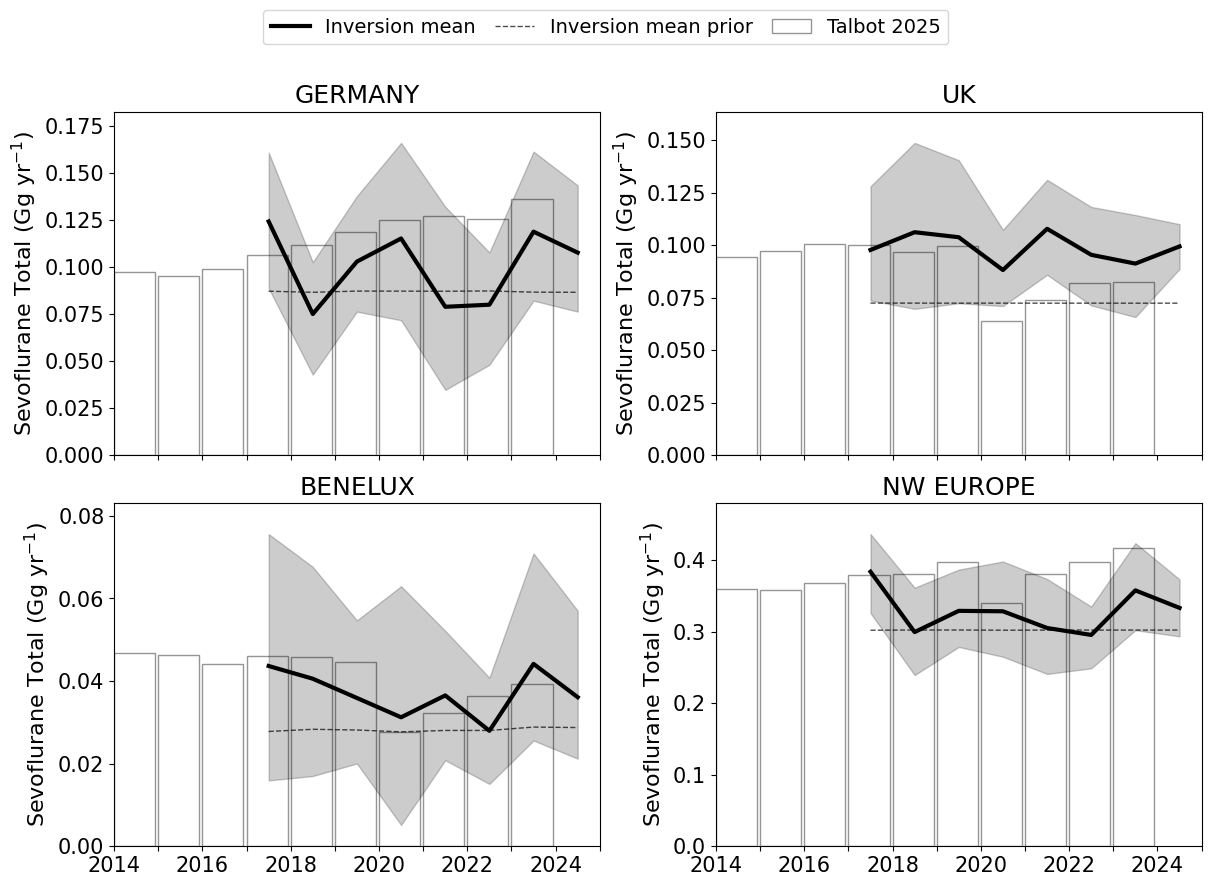

In [19]:
from fluxy.plots.flux_timeseries import plot_country_flux

###################################
### edit variables in this block
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
add_post_unc = True
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = False #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_combined = True  #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = True #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = False ##If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
###################################

fig = plot_country_flux(ds_all_flux_scaled,
                        species,
                        regions,
                        config_data,
                        model_colors,
                        model_labels,
                        start_date,
                        end_date,
                        annex_mode,
                        plot_inventory,
                        inventory_years,
                        inventory_filename,
                        inventory_label="Talbot",
                        data_dir=data_dir,
                        fix_y_axes=fix_y_axes,
                        add_prior=add_prior,
                        add_prior_unc=add_prior_unc,
                        add_post_unc=add_post_unc,
                        set_global_leg=set_global_leg,
                        country_codes_as_titles=country_codes_as_titles,
                        plot_separate=plot_separate,
                        plot_combined=plot_combined,
                        resample=resample,
                        resample_uncert_correlation=resample_uncert_correlation,
                        plot_resample_and_original=plot_resample_and_original,
                        rolling_mean=rolling_mean,
                        return_res=False,sector=sector)


fn_pdf = plot_dir + "/" + species + "_country_flux_time_series_all_models.pdf"
fig.savefig(fn_pdf, bbox_inches='tight', pad_inches=0.2, dpi=300)
fn_png = plot_dir + "/" + species + "_country_flux_time_series_all_models.png"
fig.savefig(fn_png, bbox_inches='tight', pad_inches=0.2, dpi=300)


### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_mf
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels

###################################
### edit variables in this block
site = 'MHD'
intake_height = None
period = 'yearly'  #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
mf_units_print = 'ppt'
start_date = '2014-01-01' #inclusive
end_date = '2025-01-01'   #not inclusive
baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
baseline_filename = 'InTEM_baseline_timestamps'
get_labels_from_file = True  # If False, uses default labels. If True, uses labels from config file.
read_standard_run = False
###################################

ds_all_mf = read_model_output(data_dir,'concentration',species,models,config_data,period=period,read_standard_run=read_standard_run)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              baseline_filename=baseline_filename,data_dir=data_dir,
                              mf_units_print=mf_units_print,intake_height=intake_height)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

#### Plot timestamps with data at each site:

In [ ]:
from fluxy.plots.mf_timeseries import plot_sites_timeseries

separate_by_height = False      #If True, plots data split by site and by height

fig = plot_sites_timeseries(ds_all_mf,'mf_posterior',species,start_date,end_date,model_colors,model_labels,config_data,margin=0.2,
                            separate_by_height=separate_by_height)

fn_png = plot_dir + "/" + species + "_assimilatedObservation.png"
fig.savefig(fn_png, bbox_inches='tight', pad_inches=0.2, dpi=300)


Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
from fluxy.plots.mf_timeseries import plot_mf_timeseries

###################################
### edit variables in this block
# Variables and respective uncertainties to plot
include = {'mf_observed'   : None,
           'mf_prior' : 'percentile_mf_prior',
           'mf_posterior' : 'percentile_mf_posterior'
           }

# To plot the histogram of the variables in "include", set "diff_include" to None
# To plot the histogram of Obs-variable, set "diff_include" to the desired variable to be subtracted
diff_include = [ 'mf_prior', 'mf_posterior']

# To choose y-axis limits set y_lim=[min_value,max_value]
y_lim = None
###################################

###################################
### options for variables to include
# mf_observed         - total observed mole fraction
# mf_prior            - prior total mole fraction
# mf_posterior        - posterior total mole fraction
# mf_bc_prior         - prior baseline
# mf_bc_posterior     - posterior baseline
# mf_bias_prior       - prior bias added to site
# mf_bias_posterior   - posterior bias added to site
# mf_outer_prior      - prior mole fractions only from outer regions
# mf_outer_posterior  - posterior mole fractions only from outer regions
# stdev_mf_observed_repeatability - observed repeatability mole fraction uncertainty
# stdev_mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model                  - model mole fraction uncertainty
# stdev_mf_total                  - total mole fraction uncertainty

### options for uncertainties to plot as error bars/shaded area
# stdev_mf_observed_repeatability - observed repeatability mole fraction uncertainty
# stdev_mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model                  - model mole fraction uncertainty
# stdev_mf_total                  - total mole fraction uncertainty
# percentile_mf_prior             - prior mole fraction uncertainty
# percentile_mf_posterior         - posterior mole fraction uncertainty
###################################

fig = plot_mf_timeseries(ds_all_mf_sliced,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='separate',
                                    include=include,
                                    diff_include=diff_include,
                                    y_lim=y_lim,intake_height=intake_height)

fn_png = plot_dir + "/" + species + "_" + site + "_timeseries_moleFraction_allModels.png"
fig.savefig(fn_png, bbox_inches='tight', pad_inches=0.2, dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
from fluxy.operators.select import slice_mf
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_stats_mf


###################################
### edit variables in this block
stats_to_plot = ['pearson', 'bias', 'crmse']

stats_ylim = {"pearson": [0,1], "bias": [-1.5,0.5], "crmse": [0,1.5] }    # or set it to None
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.


### Implemented statistics (stats_to_plot)
# pearson - Pearson correlation coefficient
# bias    - Mean difference
# rmse    - RMSE
# nrmse   - Normalised RMSE (division by mean observation)
# crmse   - Centered (bias-corrected) RMSE
# std_obs  - Standard deviation of observations 
# std_sim  - Standard deviation of simulation 
# std_res  - Standard deviation of residuals
# nn      - Number of observation-simulation pairs 
###################################

ds_all_allsites = slice_mf(ds_all_mf.copy(), 
                        start_date,
                        end_date,site=None,
                        baseline_site=baseline_site,
                        baseline_filename=baseline_filename,
                        data_dir=data_dir,
                        mf_units_print=mf_units_print)

model_labels = set_model_labels(models,config_data,get_labels_from_file)

what_to_compare = 'prior_above_BC'
stats = stats_mf(ds_all_allsites, stats_type=what_to_compare)

stats_ylim["bias"] = [ -max(abs(stats.bias)), max(abs(stats.bias)) ]
stats_ylim["crmse"] = [ 0, max(stats.crmse) ]


fig = plot_stats_mf(stats=stats, 
                    stats_to_plot=stats_to_plot, 
                    species=species,
                    model_colors=model_colors, 
                    model_labels=model_labels, 
                    config_data=config_data, 
                    mf_units_print=mf_units_print,
                    stats_type=what_to_compare,
                    stats_ylim=stats_ylim,
                    start_date=start_date, 
                    end_date=end_date)

fn_pdf = plot_dir + "/" + species + "_moleFraction_performanceStats_prior.pdf"
fig.savefig(fn_pdf, bbox_inches='tight', pad_inches=0.2, dpi=300)

what_to_compare = 'posterior_above_BC'
stats = stats_mf(ds_all_allsites, stats_type=what_to_compare)

fig = plot_stats_mf(stats=stats, 
                    stats_to_plot=stats_to_plot, 
                    species=species,
                    model_colors=model_colors, 
                    model_labels=model_labels, 
                    config_data=config_data, 
                    mf_units_print=mf_units_print,
                    stats_type=what_to_compare,
                    stats_ylim=stats_ylim,
                    start_date=start_date, 
                    end_date=end_date)
fn_pdf = plot_dir + "/" + species + "_moleFraction_performanceStats_posterior.pdf"
fig.savefig(fn_pdf, bbox_inches='tight', pad_inches=0.2, dpi=300)



#### Plot Taylor Diagrams

In [ ]:
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_taylor_diagram

###################################
### edit variables in this block
include = ['prior_above_BC','posterior_above_BC'] # Variables to include in the Taylor diagram
plot_type_model = 'together' #  If 'separate', plots each model in a separate subplot. If 'together', plots all models in the same subplot.
plot_type_stat = 'together'  # If 'separate', plots each statistic in a separate subplot. If 'together', plots all statistics in the same subplot.
normalize = True # If True, normalizes the data by the standard deviation of the observations. If False, plots the absolute data.
stat_markers = ['.', 'o'] # Marker styles used to plot the stats specified in the `include` parameter, sharing the same index. 
std_range = [0, 1.5] # Range for the standard deviation axis, in units provided with `std_unit` if `normalize` = True.
check_sites = False # If True, color different sites with different colors
###################################

model_labels = set_model_labels(models, config_data, get_labels_from_file)

stats = {}
for stat in include:
    stats[stat] = stats_mf(ds_all_allsites, stats_type=stat)

fig = plot_taylor_diagram(
    stats=stats,
    model_colors=model_colors,
    model_labels=model_labels,
    stat_markers=stat_markers,
    normalize=normalize,
    plot_type_model=plot_type_model,
    plot_type_stat=plot_type_stat,
    include=include,
    std_range=std_range,
    std_unit=mf_units_print,
    check_sites=check_sites
)

fn_pdf = plot_dir + "/" + species + "_moleFraction_performanceStats_TaylorPlot.pdf"
fig.savefig(fn_pdf, bbox_inches='tight', pad_inches=0.2, dpi=300)



Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Spatial maps of country/region fluxes

In [ ]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_labels
from fluxy.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
start_date = '2016-01-01' 
end_date = '2025-01-01'
period = 'yearly' # inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
flux_units_print = 'kg km-2 yr-1'
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.
add_sites_to_flux = True # If true, add sites variable to flux dataset.
sector_file = None   #if not None, adds sector level results, by scaling model totals by the sector proportions in this file, default 'EUROPE_EDGAR'
sectors = ['total']       #sectors to add to model ds, using sector_proportions_file, options for: ['agriculture','waste','energy','industry']
read_standard_run = False
###################################

ds_all_flux = read_model_output(data_dir, "flux", species, models, config_data, period=period, add_sites_to_flux=add_sites_to_flux, read_standard_run=read_standard_run)

ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,flux_units_print=flux_units_print)

model_labels = set_model_labels(models, config_data, get_labels_from_file)

if sector_file is not None:
    for m in models:
        ds_all_flux_scaled[m] = scale_by_sector_proportions(data_dir=data_dir,ds=ds_all_flux_scaled[m],
                                                            species=species,sectors=sectors,regions=None,
                                                            country_flux_units_print=None,
                                                            config_data=config_data,
                                                            sector_file=sector_file,
                                                            create_region_sector_totals=False)

##### Prior and posterior fluxes comparison across models

In [ ]:
from fluxy.plots.flux_map import plot_flux_map

###################################
### edit variables in this block
region = [ -11, 25, 35, 65 ]
add_sites = True
add_markers = False # ['london'] # Add a marker at given locations, options for 'paris', 'london', ... or any value [lon, lat]
season = None # If specified, plot the seasonal mean (only valable for monthly data), options for 'DJF', 'MAM', 'JJA' and 'SON'
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
if species=='sf6':
    set_fluxlim = [0, 1]
plot_inversion_grid_flux = True # If True, plot fluxes at inversion's resolution. If False, plot fluxes at prior's resolution.
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
###################################

fig = plot_flux_map(ds_all_flux_scaled, species, region, config_data, model_labels, season=season,
                    add_sites=add_sites, add_markers=add_markers, set_fluxlim=set_fluxlim, 
                    plot_inversion_grid_flux=plot_inversion_grid_flux,sector=sector)

fn_png = plot_dir + "/" + species + "_map_fluxAverage_allModels.png"
fig.savefig(fn_png, bbox_inches='tight', pad_inches=0.2, dpi=300)


##### Plot prior, posterior or difference fluxes per time interval:

In [ ]:
from fluxy.plots.flux_map import plot_flux_map_over_time


chop_by = 'year' # Time unit of the averaging period (options for 'year', 'month' and 'season').
                 # Alternatively, a list of starting dates can be provided (format '2018-01-01') or a list of months (e.g., [[1:3], [7:9]])
dt = 5  # Number of time steps for year and month chop_by options
plot_combined = True
add_sites = True    
add_markers = False
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
sector = 'total'     # default 'total', otherwise chosen single sector plotted for all models
var = f'flux_{sector}_posterior_inversion_grid'  # Variable to be plotted. Extra options for 'posterior_prior_diff', 'posterior_mean_diff', 'posterior_prior_diff_inversion_grid', 'posterior_mean_diff_inversion_grid'.
###################################

fig = plot_flux_map_over_time(ds_all_flux_scaled, var, species,region,config_data, model_labels, chop_by=chop_by, dt=dt,
                              plot_combined=plot_combined, add_sites=add_sites, add_markers=add_markers, 
                              set_fluxlim = set_fluxlim,sector=sector)


fn_pdf = plot_dir + "/" + species + "_map_fluxOverTime_modelAverage.pdf"
fig.savefig(fn_pdf, bbox_inches='tight', pad_inches=0.2, dpi=300)

fn_png = plot_dir + "/" + species + "_map_fluxOverTime_modelAverage.png"
fig.savefig(fn_png, bbox_inches='tight', pad_inches=0.2, dpi=300)

